# Week 4 – Model Explainability and Fairness

## 0. Imports

In [65]:
import sys, os, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import scipy.sparse as sp

from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics         import classification_report

from features   import clean_texts_batch, extract_features_batch
from evaluate   import compute_metrics, get_misclassified
from shap_utils import (build_tfidf_explainer, build_linguistic_explainer,
                         global_token_importance, global_linguistic_importance,
                         individual_shap_breakdown, plot_global_token_importance,
                         plot_waterfall, plot_linguistic_feature_importance,
                         plot_shap_heatmap, get_token_highlights)
from fairness   import (compute_group_metrics, demographic_parity_difference,
                         print_fairness_report, plot_fairness_bars,
                         plot_per_class_fairness, plot_prediction_distribution)

plt.rcParams.update({'figure.dpi':130,'font.family':'DejaVu Sans',
                     'axes.spines.top':False,'axes.spines.right':False})
DOCS = '../docs'
RANDOM_STATE = 42
os.makedirs(DOCS, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load data + retrain TF-IDF model for SHAP


In [66]:
combined = '../data/processed/features_combined.csv'
kaggle   = '../data/processed/features_kaggle.csv'
data_path = combined if os.path.exists(combined) else kaggle
print(f'Using: {os.path.basename(data_path)}')

feat_df = pd.read_csv(data_path)
le      = joblib.load('../models/label_encoder.pkl')
vec     = joblib.load('../models/tfidf_vectorizer.pkl')

texts    = feat_df['text_clean'].fillna('').tolist()
y        = le.transform(feat_df['label'])
X_tfidf  = vec.transform(texts)

ling_cols = [c for c in feat_df.columns
             if c not in ['label','label_enc','text_clean','source']]
X_ling    = feat_df[ling_cols].fillna(0).values

print(f'TF-IDF: {X_tfidf.shape} | Linguistic: {X_ling.shape}')
print(f'Classes: {le.classes_}')

(X_tr_t, X_te_t, X_tr_l, X_te_l,
 y_tr,   y_te,  idx_tr, idx_te) = train_test_split(
    X_tfidf, X_ling, y, np.arange(len(y)),
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
texts_te = [texts[i] for i in idx_te]

print('\nTraining LR-TF-IDF (token SHAP)...')
lr_tfidf = LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=RANDOM_STATE, C=1.0)
lr_tfidf.fit(X_tr_t, y_tr)
y_pred_tfidf = lr_tfidf.predict(X_te_t)
print(f'LR-TF-IDF test F1-macro: {compute_metrics(y_te, y_pred_tfidf, le.classes_.tolist())["f1_macro"]:.4f}')

print('Training LR-Ling (feature SHAP)...')
lr_ling = LogisticRegression(class_weight='balanced', max_iter=1000,
                              random_state=RANDOM_STATE, C=1.0)
lr_ling.fit(X_tr_l, y_tr)
y_pred_ling = lr_ling.predict(X_te_l)
print(f'LR-Ling  test F1-macro: {compute_metrics(y_te, y_pred_ling, le.classes_.tolist())["f1_macro"]:.4f}')

joblib.dump(lr_tfidf, '../models/lr_tfidf_shap.pkl', compress=3)
joblib.dump(lr_ling,  '../models/lr_ling_shap.pkl',  compress=3)
print('\nModels saved.')

Using: features_kaggle.csv
TF-IDF: (35631, 10000) | Linguistic: (35631, 24)
Classes: ['high' 'low']

Training LR-TF-IDF (token SHAP)...
LR-TF-IDF test F1-macro: 0.9247
Training LR-Ling (feature SHAP)...
LR-Ling  test F1-macro: 0.7499

Models saved.


## 2. Build SHAP explainers

In [67]:
explainer_tfidf = build_tfidf_explainer(lr_tfidf, X_tfidf)

explainer_ling  = build_linguistic_explainer(lr_ling, X_ling)

feat_names_tfidf = list(vec.get_feature_names_out())

print(f'TF-IDF explainer ready — {len(feat_names_tfidf)} features')
print(f'Linguistic explainer ready — {len(ling_cols)} features')

TF-IDF explainer ready — 10000 features
Linguistic explainer ready — 24 features


## 3. Global token importance

  high      : ['depression', 'life', 'die', 'feel', 'want', 'kill', 'redflag', 'anymore', 'im', 'know']
  low       : ['depression', 'life', 'die', 'feel', 'want', 'kill', 'redflag', 'anymore', 'im', 'know']


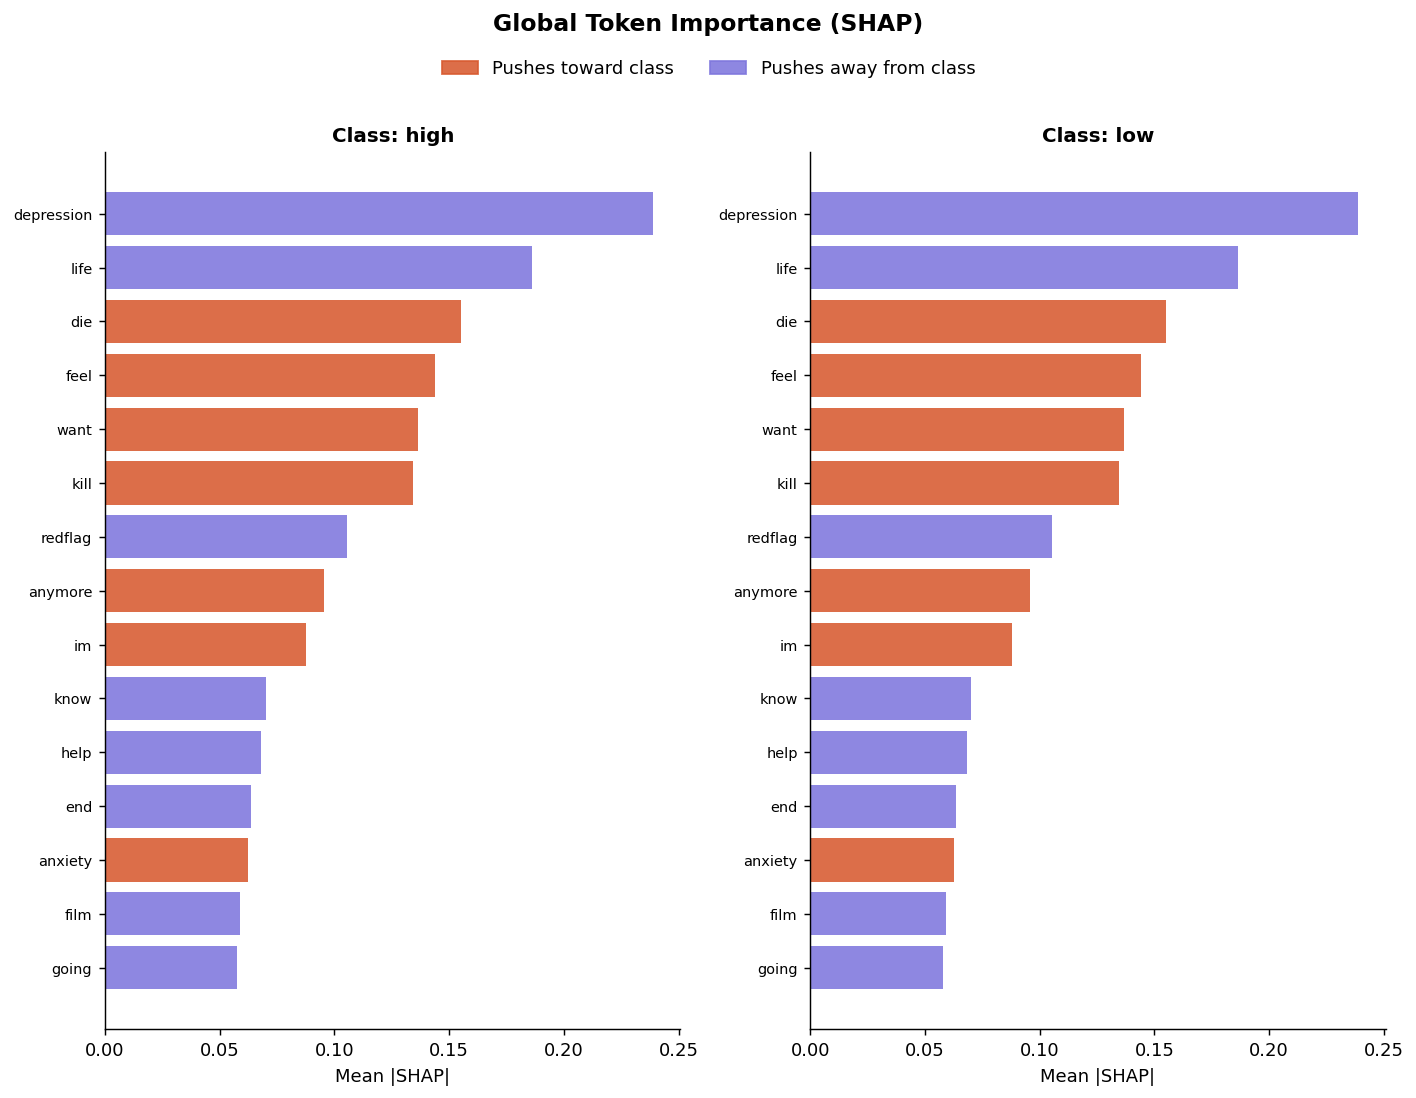

In [68]:
importance_tfidf = global_token_importance(
    explainer_tfidf, X_te_t, feat_names_tfidf, le.classes_.tolist(), top_n=20
)

for cls in le.classes_:
    tokens = importance_tfidf[cls]['feature'].head(10).tolist()
    print(f"  {cls:10}: {tokens}")

plot_global_token_importance(
    importance_tfidf, le.classes_.tolist(),
    save_path=f'{DOCS}/plot_shap_global_tokens.png'
)


## 4. Linguistic feature importance


  high:
          feature  mean_shap
fp_singular_count   7.693258
         char_len  -3.291999
       word_count   2.737265
     avg_sent_len   2.737265
   negation_count   0.690318

  low:
          feature  mean_shap
fp_singular_count   7.693258
         char_len  -3.291999
       word_count   2.737265
     avg_sent_len   2.737265
   negation_count   0.690318


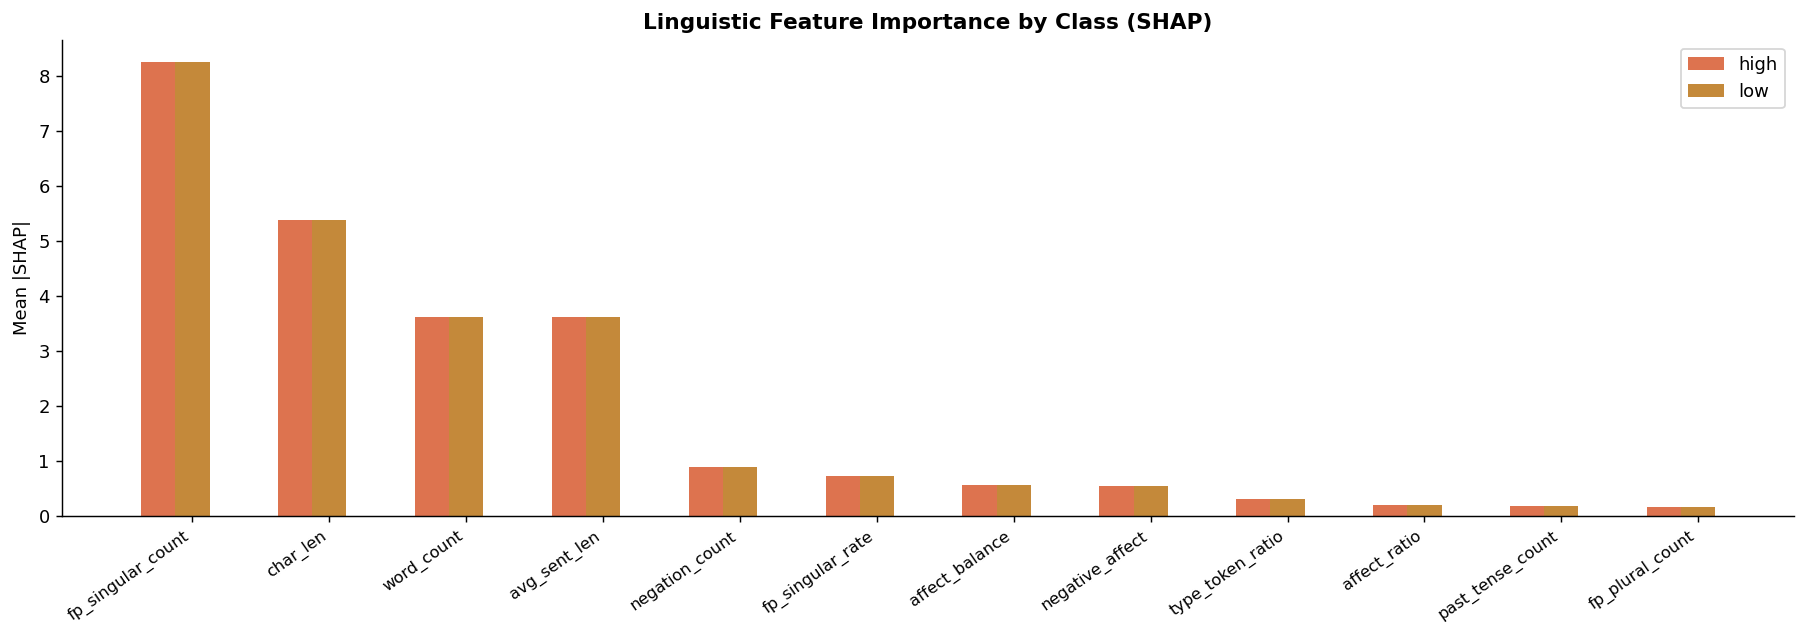

In [69]:
importance_ling = global_linguistic_importance(
    explainer_ling, X_te_l, ling_cols, le.classes_.tolist(), top_n=12
)

for cls in le.classes_:
    feats = importance_ling[cls][['feature','mean_shap']].head(5).to_string(index=False)
    print(f"\n  {cls}:\n{feats}")

plot_linguistic_feature_importance(
    importance_ling, le.classes_.tolist(),
    save_path=f'{DOCS}/plot_shap_linguistic.png'
)


## 5. SHAP heatmap

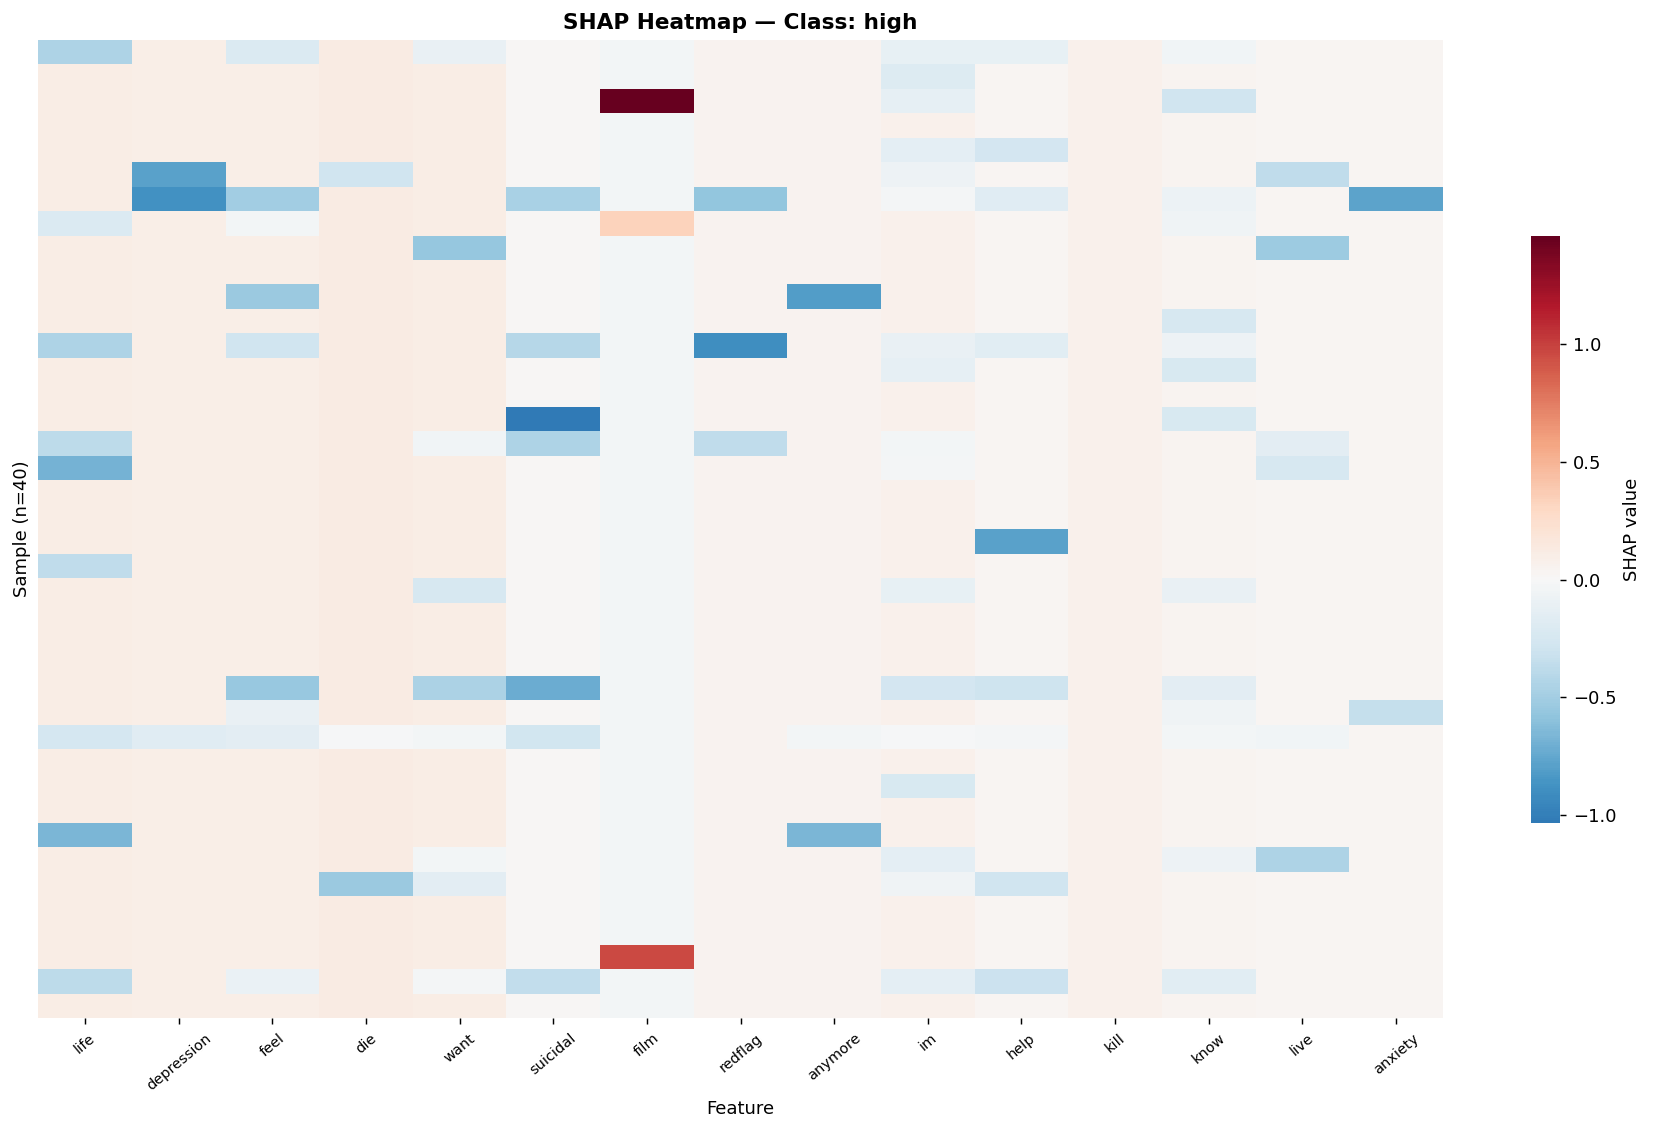

In [70]:
high_idx = list(le.classes_).index('high')

plot_shap_heatmap(
    explainer_tfidf, X_te_t, feat_names_tfidf, le.classes_.tolist(),
    class_idx=high_idx, n_samples=40, top_n_features=15,
    save_path=f'{DOCS}/plot_shap_heatmap.png'
)


## 6. Example predictions


Example: Correct prediction
True: high  |  Predicted: high
Text: "emotions break facade caring hurts mostso might little older you life sucks knew person believe could feel way true happ..."
  feature  shap_value       direction
     life   -0.457298   ↓ pushes away
     pain   -0.359421   ↓ pushes away
    movie    0.244757 ↑ pushes toward
     pill   -0.225485   ↓ pushes away
     feel   -0.212207   ↓ pushes away
      end   -0.166613   ↓ pushes away
 sleeping   -0.166250   ↓ pushes away
    point   -0.160008   ↓ pushes away
     care   -0.156772   ↓ pushes away
pointless   -0.156300   ↓ pushes away


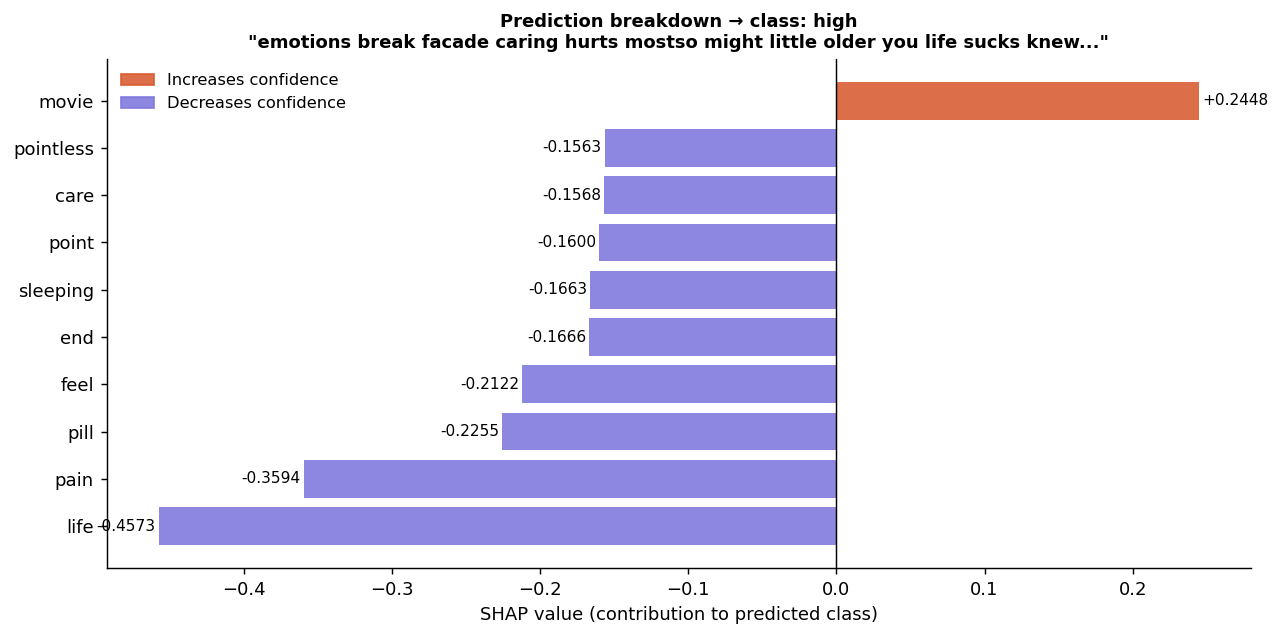


Example: Misclassification
True: low  |  Predicted: high
Text: "miss leave man feel empty inside friendships falling apart motivation anything anymore..."
      feature  shap_value       direction
      anymore   -0.817415   ↓ pushes away
         feel   -0.538683   ↓ pushes away
          man    0.360048 ↑ pushes toward
      falling   -0.345773   ↓ pushes away
        leave   -0.308532   ↓ pushes away
falling apart   -0.255959   ↓ pushes away
   motivation   -0.244786   ↓ pushes away
         miss    0.240677 ↑ pushes toward
        apart   -0.218235   ↓ pushes away
          die    0.119313 ↑ pushes toward


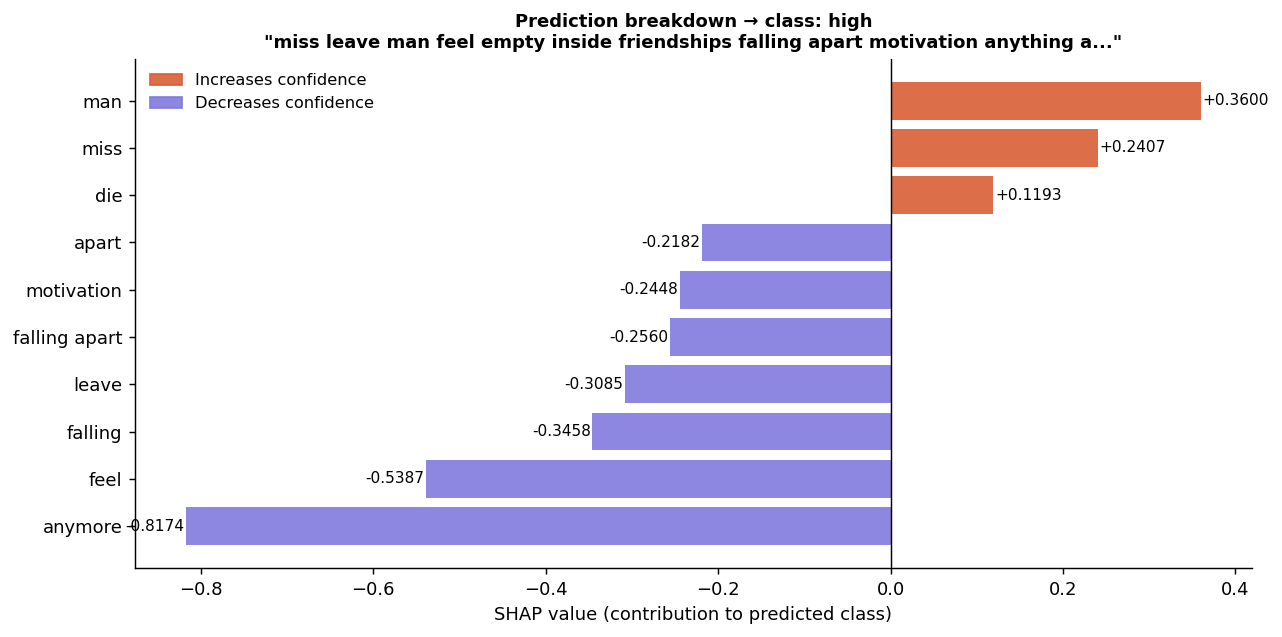


Example: Borderline (low confidence)
True: high  |  Predicted: low
Text: "say turning one things look forward tohow spent th birthday weeks ago knee praying hours friend got shot safe makes aliv..."
     feature  shap_value       direction
       alive   -0.616862   ↓ pushes away
        live   -0.358873   ↓ pushes away
      longer   -0.339754   ↓ pushes away
     forward   -0.237781   ↓ pushes away
       spent   -0.224305   ↓ pushes away
look forward   -0.207646   ↓ pushes away
         ago   -0.181925   ↓ pushes away
       grief   -0.174664   ↓ pushes away
     picture    0.171879 ↑ pushes toward
        knee    0.161756 ↑ pushes toward


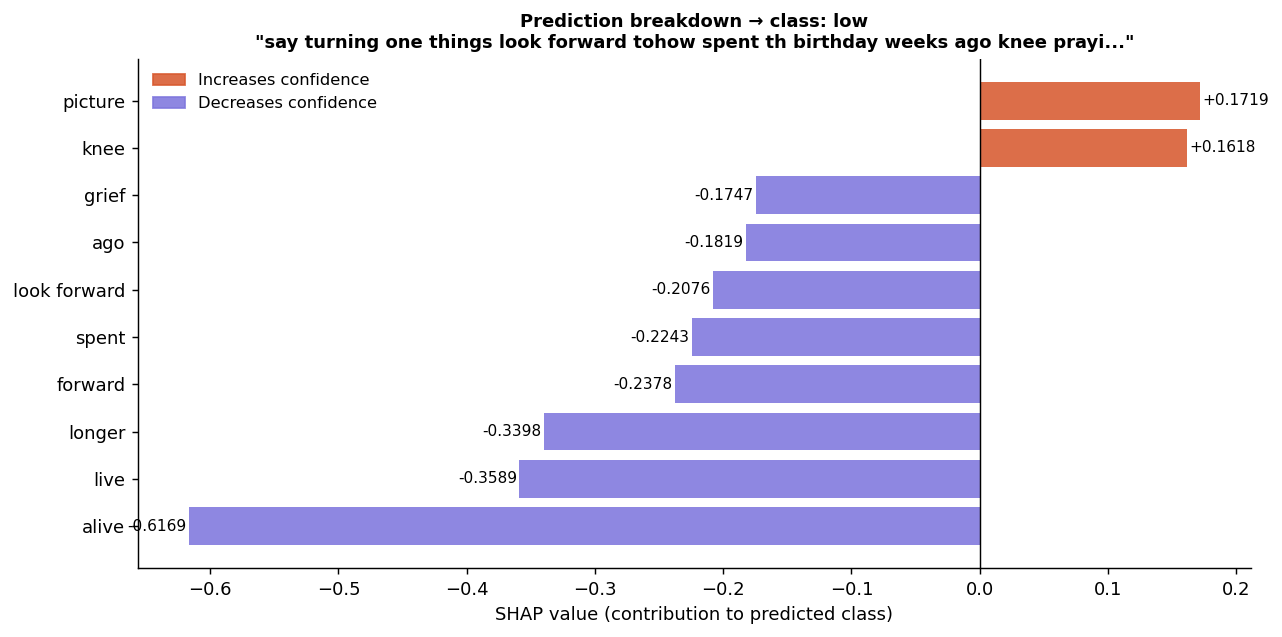

In [71]:
proba = lr_tfidf.decision_function(X_te_t)
conf_score = np.abs(proba)
correct_idx   = np.where(y_pred_tfidf == y_te)[0][0]
wrong_mask    = y_pred_tfidf != y_te
borderline_idx = conf_score.argsort()[0]  # lowest confidence
wrong_idx     = np.where(wrong_mask)[0][0] if wrong_mask.any() else correct_idx + 1

cases = [
    (correct_idx,   'Correct prediction'),
    (wrong_idx,     'Misclassification'),
    (borderline_idx,'Borderline (low confidence)'),
]

for case_idx, case_label in cases:
    true_cls = le.classes_[y_te[case_idx]]
    pred_cls = le.classes_[y_pred_tfidf[case_idx]]
    pred_cls_idx = int(y_pred_tfidf[case_idx])

    print(f"\nExample: {case_label}")
    print(f'True: {true_cls}  |  Predicted: {pred_cls}')
    print(f'Text: "{texts_te[case_idx][:120]}..."')

    breakdown = individual_shap_breakdown(
        explainer_tfidf, X_te_t[case_idx],
        feat_names_tfidf, le.classes_.tolist(),
        predicted_class_idx=pred_cls_idx, top_n=10
    )
    print(breakdown.to_string(index=False))

    plot_waterfall(
        breakdown, predicted_class=pred_cls,
        text_preview=texts_te[case_idx],
        save_path=f'{DOCS}/plot_waterfall_{case_label.split()[0].lower()}.png'
    )


## 7. Testing token importance

In [72]:
examples = [
    "I feel completely hopeless and cannot see any reason to continue.",
    "Had a great week, feeling energetic and motivated about my goals.",
    "Not sure how I'm feeling. Some days are okay, others are really hard.",
]

print('Top contributing tokens:')
for text in examples:
    highlights = get_token_highlights(text, explainer_tfidf, vec, top_n=5)
    print(f'\nText: "{text[:60]}..."')
    print(f'Prediction: {le.classes_[lr_tfidf.predict(vec.transform([text]))[0]]}')
    for h in highlights:
       print(f'{h["token"]:<20} SHAP={h["shap"]:+.4f}')

Top contributing tokens:

Text: "I feel completely hopeless and cannot see any reason to cont..."
Prediction: high
hopeless             SHAP=-0.8443
feel                 SHAP=-0.7048
reason               SHAP=-0.6382
continue             SHAP=-0.6095
completely           SHAP=-0.1896

Text: "Had a great week, feeling energetic and motivated about my g..."
Prediction: low
feeling              SHAP=-0.4683
great                SHAP=+0.4165
goals                SHAP=-0.2199
week                 SHAP=-0.1392
energetic            SHAP=-0.1238

Text: "Not sure how I'm feeling. Some days are okay, others are rea..."
Prediction: low
sure                 SHAP=-0.6439
feeling              SHAP=-0.6044
really               SHAP=-0.3184
hard                 SHAP=-0.2624
days                 SHAP=-0.2304


## 8. Fairness audit

In [73]:

np.random.seed(42)
groups_all = np.random.choice(
    ['Male', 'Female', 'Non-binary'], size=len(y),
    p=[0.45, 0.45, 0.10]
)
groups_te = groups_all[idx_te]
print("Fairness analysis")
group_metrics = compute_group_metrics(
    y_te, y_pred_tfidf, groups_te,
    class_names=le.classes_.tolist(),
    high_risk_label='high', min_group_size=5
)

print_fairness_report(group_metrics, le.classes_.tolist())


Fairness analysis

Group-level performance (3 groups):
     group    n  f1_macro  recall_macro  f1_high  f1_low  recall_high_risk
    Female 3204    0.9251        0.9254   0.9253  0.9249            0.9100
      Male 3272    0.9240        0.9237   0.9206  0.9275            0.9072
Non-binary  651    0.9261        0.9258   0.9226  0.9296            0.9137

Disparity measures:
DPD (f1_macro): 0.0021
DPD (recall_macro): 0.0021
DPD (recall_high_risk): 0.0065


## 9. Fairness analysis

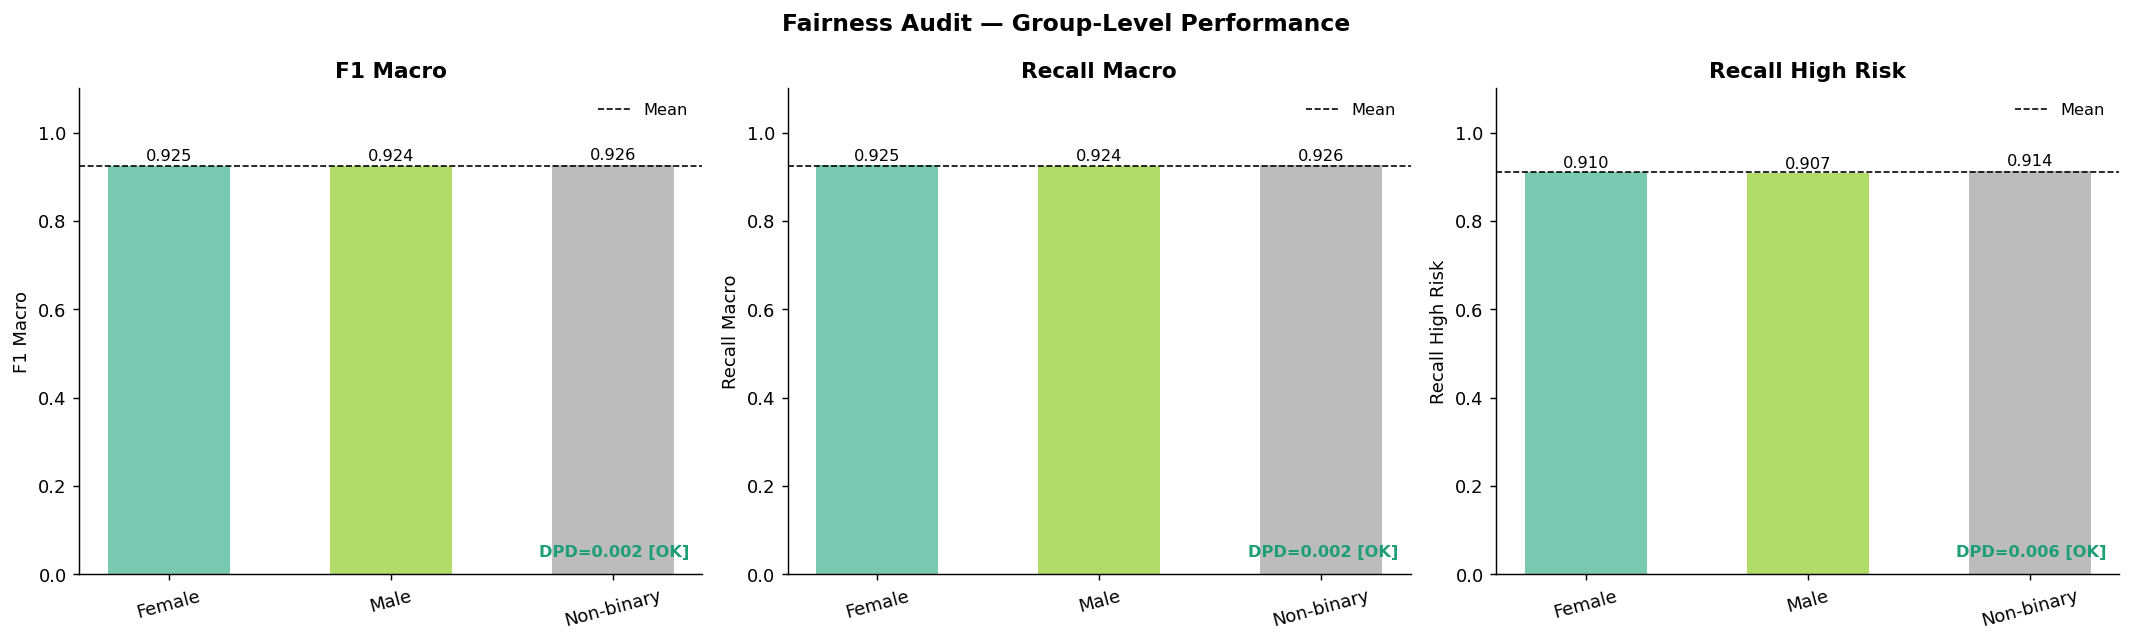

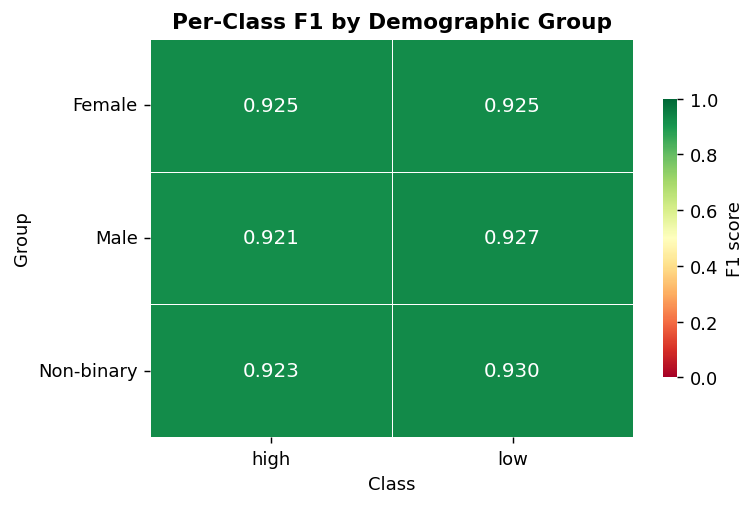

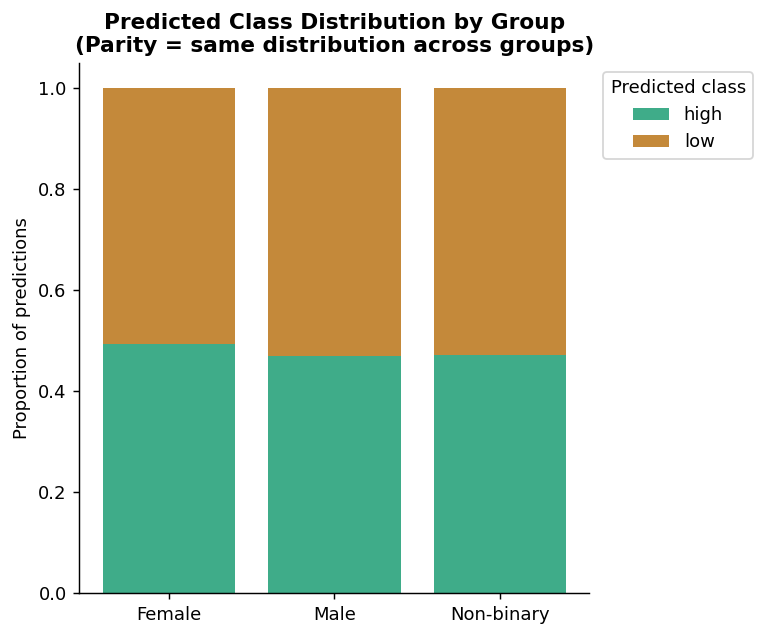

In [74]:
plot_fairness_bars(
    group_metrics, le.classes_.tolist(),
    save_path=f'{DOCS}/plot_fairness_bars.png'
)

plot_per_class_fairness(
    group_metrics, le.classes_.tolist(),
    save_path=f'{DOCS}/plot_fairness_heatmap.png'
)

plot_prediction_distribution(
    y_pred_tfidf, groups_te, le.classes_.tolist(),
    save_path=f'{DOCS}/plot_pred_distribution.png'
)


## 10. Error analysis

In [75]:
errors = get_misclassified(texts_te, y_te, y_pred_tfidf, le.classes_.tolist(), n=20)
print(f'Total errors: {len(errors)} ({len(errors)/len(y_te)*100:.1f}%)')

# For each error type, pull SHAP explanation
if len(errors) > 0:
    print("\nSample misclassified posts:")
    for _, row in errors.head(3).iterrows():
        i = int(row['index'])
        pred_cls_idx = int(y_pred_tfidf[i])
        breakdown = individual_shap_breakdown(
            explainer_tfidf, X_te_t[i],
            feat_names_tfidf, le.classes_.tolist(),
            predicted_class_idx=pred_cls_idx, top_n=5
        )
        print(f"\n  [{row['error_type']}]: '{texts_te[i][:80]}...'")
        for _, br in breakdown.iterrows():
            print(f"    {br['direction']} '{br['feature']}' ({br['shap_value']:+.4f})")


Error type breakdown:
error_type
low → high    11
high → low     9
Name: count, dtype: int64

Total errors: 20 (0.3%)

Sample misclassified posts:

  [low → high]: 'miss leave man feel empty inside friendships falling apart motivation anything a...'
    ↓ pushes away 'anymore' (-0.8174)
    ↓ pushes away 'feel' (-0.5387)
    ↑ pushes toward 'man' (+0.3600)
    ↓ pushes away 'falling' (-0.3458)
    ↓ pushes away 'leave' (-0.3085)

  [low → high]: 'hardexpensive live ur started literally everyone know desk bedroom like basic te...'
    ↓ pushes away 'live' (-0.4473)
    ↑ pushes toward 'teenagers' (+0.2523)
    ↓ pushes away 'job' (-0.2207)
    ↑ pushes toward 'ur' (+0.2135)
    ↓ pushes away 'point' (-0.2000)

  [low → high]: 'friend going shit post supposed funny friend going shit want help idk how told n...'
    ↓ pushes away 'help' (-0.7564)
    ↓ pushes away 'going' (-0.3551)
    ↓ pushes away 'talk' (-0.2750)
    ↓ pushes away 'told' (-0.2401)
    ↓ pushes away 'want' (-0.1590)
